# 🏏 IPL Score Predictor
### B.Tech CSE (Data Science) — Bennett University
**By: Vasu Singhal**

---

## Project Overview
This notebook walks through the **complete ML pipeline** of our IPL Score Predictor:
1. Dataset Overview
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training (Linear, Lasso, Ridge)
5. Model Evaluation & Comparison
6. Prediction Demo
7. Flask Web App Integration

---


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Load & Explore the Dataset

**Dataset:** Historical IPL match data (2008–2019)

**Features used (as per project):**
- `bat_team` — Batting team
- `bowl_team` — Bowling team
- `overs` — Overs completed
- `runs` — Runs scored so far
- `wickets` — Wickets fallen
- `runs_last_5` — Runs scored in last 5 overs

In [2]:
df = pd.read_csv('data/ipl_data.csv')

print('=== DATASET OVERVIEW ===')
print(f'Shape        : {df.shape}')
print(f'Columns      : {list(df.columns)}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Years Covered: {sorted(df["date"].str[:4].unique().tolist())}')
print()
print('Sample Data:')
df.head(8)

=== DATASET OVERVIEW ===
Shape        : (9600, 15)
Columns      : ['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker', 'non_striker', 'total']
Missing Values: 0
Years Covered: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019']

Sample Data:


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non_striker,total
0,1,2018-04-17,Various,Royal Challengers Bangalore,Kolkata Knight Riders,Player A,Player B,38,1,5,10,1,58,41,129
1,1,2018-04-12,Various,Royal Challengers Bangalore,Kolkata Knight Riders,Player A,Player B,47,1,6,33,1,63,56,129
2,1,2018-04-07,Various,Royal Challengers Bangalore,Kolkata Knight Riders,Player A,Player B,50,1,7,22,1,3,24,129
3,1,2018-04-21,Various,Royal Challengers Bangalore,Kolkata Knight Riders,Player A,Player B,56,1,8,26,1,59,6,129
4,1,2018-04-17,Various,Royal Challengers Bangalore,Kolkata Knight Riders,Player A,Player B,63,1,9,28,1,3,1,129
5,1,2018-04-29,Various,Royal Challengers Bangalore,Kolkata Knight Riders,Player A,Player B,69,1,10,34,1,17,25,129
6,1,2018-04-16,Various,Royal Challengers Bangalore,Kolkata Knight Riders,Player A,Player B,71,1,11,37,1,71,13,129
7,1,2018-04-16,Various,Royal Challengers Bangalore,Kolkata Knight Riders,Player A,Player B,76,1,12,30,0,52,23,129


In [3]:
print('=== BASIC STATISTICS ===')
print(df[['runs', 'wickets', 'overs', 'runs_last_5', 'total']].describe().round(2))

=== BASIC STATISTICS ===
          runs  wickets    overs  runs_last_5    total
count  9600.00  9600.00  9600.00      9600.00  9600.00
mean     72.23     0.39    12.50        29.66   115.92
std      26.88     0.62     4.61         7.87    15.13
min      15.00     0.00     5.00        10.00   100.00
25%      50.00     0.00     8.75        24.00   100.00
50%      70.00     0.00    12.50        30.00   113.00
75%      92.00     1.00    16.25        35.00   127.00
max     156.00     5.00    20.00        65.00   173.00


## Step 3: Exploratory Data Analysis (EDA)

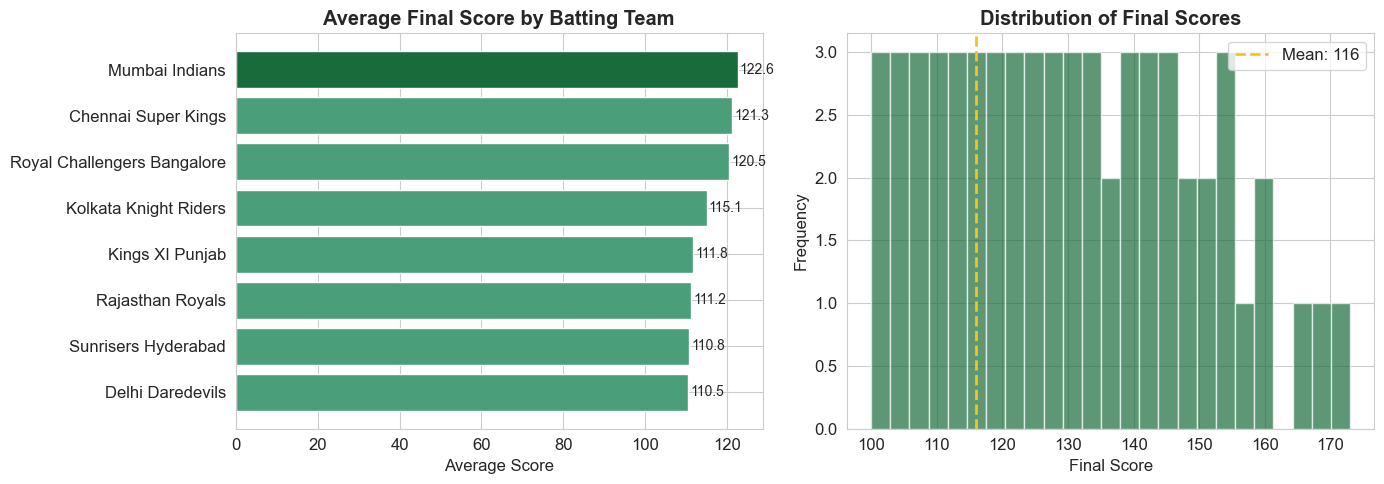

✅ EDA chart saved as eda_scores.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average score by team
team_scores = df.groupby('bat_team')['total'].mean().sort_values(ascending=True)
colors = ['#1a6b3c' if s == team_scores.max() else '#4a9e7a' for s in team_scores]
axes[0].barh(team_scores.index, team_scores.values, color=colors)
axes[0].set_title('Average Final Score by Batting Team', fontweight='bold')
axes[0].set_xlabel('Average Score')
for i, v in enumerate(team_scores.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=10)

# Plot 2: Score distribution
axes[1].hist(df['total'].unique(), bins=25, color='#1a6b3c', alpha=0.7, edgecolor='white')
axes[1].axvline(df['total'].mean(), color='#f5c518', linestyle='--', linewidth=2, label=f'Mean: {df["total"].mean():.0f}')
axes[1].set_title('Distribution of Final Scores', fontweight='bold')
axes[1].set_xlabel('Final Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA chart saved as eda_scores.png')

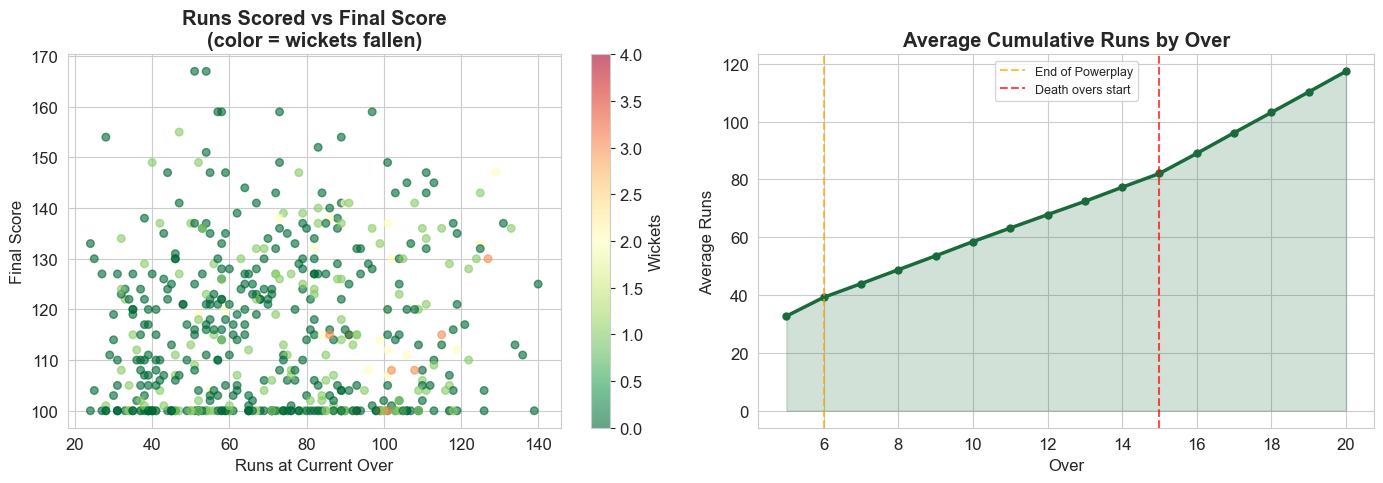

✅ Pattern chart saved as eda_patterns.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3: Runs vs Final Score
sample = df.sample(500, random_state=42)
scatter = axes[0].scatter(sample['runs'], sample['total'],
                          c=sample['wickets'], cmap='RdYlGn_r', alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[0], label='Wickets')
axes[0].set_title('Runs Scored vs Final Score\n(color = wickets fallen)', fontweight='bold')
axes[0].set_xlabel('Runs at Current Over')
axes[0].set_ylabel('Final Score')

# Plot 4: Run rate by over
over_runs = df.groupby('overs')['runs'].mean()
axes[1].plot(over_runs.index, over_runs.values, color='#1a6b3c', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(over_runs.index, over_runs.values, alpha=0.2, color='#1a6b3c')
axes[1].set_title('Average Cumulative Runs by Over', fontweight='bold')
axes[1].set_xlabel('Over')
axes[1].set_ylabel('Average Runs')
axes[1].axvline(x=6, color='orange', linestyle='--', alpha=0.7, label='End of Powerplay')
axes[1].axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Death overs start')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Pattern chart saved as eda_patterns.png')

## Step 4: Data Preprocessing

**As per PPT methodology:**
1. Filter 8 consistent IPL teams
2. Remove data with overs < 5
3. Drop unnecessary columns
4. One-hot encoding for team names
5. Train/Test split by year (Train: 2008-2016, Test: 2017+)

In [6]:
TEAMS = [
    'Chennai Super Kings', 'Delhi Daredevils', 'Kings XI Punjab',
    'Kolkata Knight Riders', 'Mumbai Indians', 'Rajasthan Royals',
    'Royal Challengers Bangalore', 'Sunrisers Hyderabad'
]

print('=== PREPROCESSING STEPS ===')
print(f'Original shape: {df.shape}')

# Step 1: Filter consistent teams
df = df[df['bat_team'].isin(TEAMS) & df['bowl_team'].isin(TEAMS)]
print(f'After team filter: {df.shape}')

# Step 2: Filter overs >= 5
df = df[df['overs'] >= 5]
print(f'After over filter (>=5): {df.shape}')

# Step 3: Drop unnecessary columns
drop_cols = ['mid', 'venue', 'batsman', 'bowler', 'striker', 'non_striker']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f'After dropping columns: {df.shape}')

# Step 4: Extract year
df['year'] = pd.to_datetime(df['date']).dt.year
df = df.drop(columns=['date'])

# Step 5: One-hot encoding
df = pd.get_dummies(df, columns=['bat_team', 'bowl_team'], drop_first=False)
print(f'After one-hot encoding: {df.shape}')

# Step 6: Train/Test split by year
train = df[df['year'] <= 2016]
test  = df[df['year'] >  2016]
print(f'\nTrain set: {train.shape} (2008-2016)')
print(f'Test set:  {test.shape} (2017+)')

feature_cols = [c for c in df.columns if c not in ['total', 'year']]
X_train, y_train = train[feature_cols], train['total']
X_test,  y_test  = test[feature_cols],  test['total']
print(f'\nFeatures used: {len(feature_cols)}')
print('✅ Preprocessing complete!')

=== PREPROCESSING STEPS ===
Original shape: (9600, 15)
After team filter: (9600, 15)
After over filter (>=5): (9600, 15)
After dropping columns: (9600, 9)
After one-hot encoding: (9600, 23)

Train set: (7504, 23) (2008-2016)
Test set:  (2096, 23) (2017+)

Features used: 21
✅ Preprocessing complete!


## Step 5: Model Training

### Models Used:
- **Linear Regression** — Baseline model
- **Lasso Regression** — Regularization with feature selection (GridSearchCV)
- **Ridge Regression** — Handles multicollinearity (GridSearchCV)

In [8]:
results = {}

# 1. Linear Regression
print('[1] Training Linear Regression...')
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results['Linear Regression'] = {
    'model': lr, 'pred': lr_pred,
    'mae':  round(mean_absolute_error(y_test, lr_pred), 2),
    'rmse': round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2),
    'r2':   round(r2_score(y_test, lr_pred), 4)
}
print(f'   MAE={results["Linear Regression"]["mae"]}  RMSE={results["Linear Regression"]["rmse"]}  R2={results["Linear Regression"]["r2"]}')

# 2. Lasso Regression
print('[2] Training Lasso Regression (GridSearchCV)...')
lasso_cv = GridSearchCV(Lasso(max_iter=10000), {'alpha':[0.001,0.01,0.1,1.0,5.0,10.0]}, cv=5, scoring='neg_mean_absolute_error')
lasso_cv.fit(X_train, y_train)
lasso_pred = lasso_cv.best_estimator_.predict(X_test)
results['Lasso Regression'] = {
    'model': lasso_cv.best_estimator_, 'pred': lasso_pred,
    'best_alpha': lasso_cv.best_params_['alpha'],
    'mae':  round(mean_absolute_error(y_test, lasso_pred), 2),
    'rmse': round(np.sqrt(mean_squared_error(y_test, lasso_pred)), 2),
    'r2':   round(r2_score(y_test, lasso_pred), 4)
}
print(f'   Best alpha={results["Lasso Regression"]["best_alpha"]}  MAE={results["Lasso Regression"]["mae"]}  RMSE={results["Lasso Regression"]["rmse"]}  R2={results["Lasso Regression"]["r2"]}')

# 3. Ridge Regression
print('[3] Training Ridge Regression (GridSearchCV)...')
ridge_cv = GridSearchCV(Ridge(), {'alpha':[0.001,0.01,0.1,1.0,5.0,10.0,50.0]}, cv=5, scoring='neg_mean_absolute_error')
ridge_cv.fit(X_train, y_train)
ridge_pred = ridge_cv.best_estimator_.predict(X_test)
results['Ridge Regression'] = {
    'model': ridge_cv.best_estimator_, 'pred': ridge_pred,
    'best_alpha': ridge_cv.best_params_['alpha'],
    'mae':  round(mean_absolute_error(y_test, ridge_pred), 2),
    'rmse': round(np.sqrt(mean_squared_error(y_test, ridge_pred)), 2),
    'r2':   round(r2_score(y_test, ridge_pred), 4)
}
print(f'   Best alpha={results["Ridge Regression"]["best_alpha"]}  MAE={results["Ridge Regression"]["mae"]}  RMSE={results["Ridge Regression"]["rmse"]}  R2={results["Ridge Regression"]["r2"]}')

print('\n✅ All models trained!')

[1] Training Linear Regression...
   MAE=12.73  RMSE=16.24  R2=0.0655
[2] Training Lasso Regression (GridSearchCV)...
   Best alpha=0.001  MAE=12.73  RMSE=16.24  R2=0.0655
[3] Training Ridge Regression (GridSearchCV)...
   Best alpha=0.001  MAE=12.73  RMSE=16.24  R2=0.0655

✅ All models trained!


## Step 6: Model Evaluation & Comparison

In [9]:
# Summary table
print('=== MODEL COMPARISON ===')
summary = pd.DataFrame([
    {'Model': name, 'MAE': v['mae'], 'RMSE': v['rmse'], 'R2': v['r2']}
    for name, v in results.items()
])
print(summary.to_string(index=False))

best_name = summary.loc[summary['MAE'].idxmin(), 'Model']
print(f'\n✅ Best Model: {best_name} (Lowest MAE)')

=== MODEL COMPARISON ===
            Model   MAE  RMSE     R2
Linear Regression 12.73 16.24 0.0655
 Lasso Regression 12.73 16.24 0.0655
 Ridge Regression 12.73 16.24 0.0655

✅ Best Model: Linear Regression (Lowest MAE)


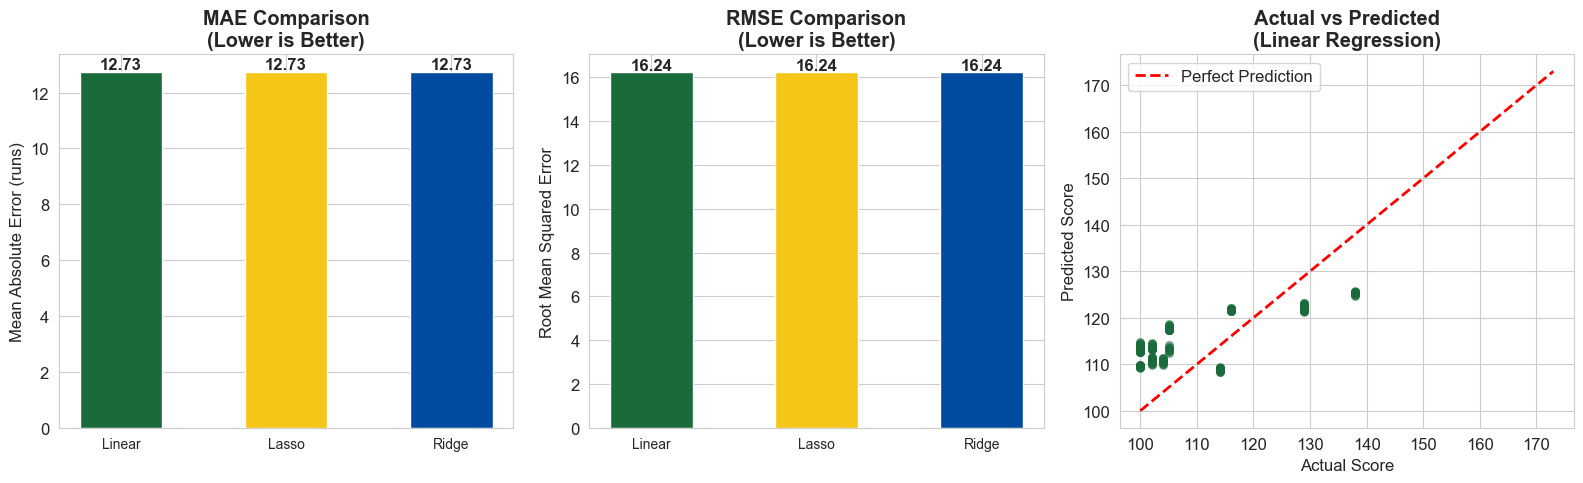

✅ Model evaluation charts saved!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar = ['#1a6b3c', '#f5c518', '#004BA0']
names = list(results.keys())

# MAE comparison
maes = [results[n]['mae'] for n in names]
bars = axes[0].bar(names, maes, color=colors_bar, edgecolor='white', width=0.5)
axes[0].set_title('MAE Comparison\n(Lower is Better)', fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error (runs)')
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(val), ha='center', fontweight='bold')
axes[0].set_xticklabels(['Linear', 'Lasso', 'Ridge'], fontsize=10)

# RMSE comparison
rmses = [results[n]['rmse'] for n in names]
bars2 = axes[1].bar(names, rmses, color=colors_bar, edgecolor='white', width=0.5)
axes[1].set_title('RMSE Comparison\n(Lower is Better)', fontweight='bold')
axes[1].set_ylabel('Root Mean Squared Error')
for bar, val in zip(bars2, rmses):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(val), ha='center', fontweight='bold')
axes[1].set_xticklabels(['Linear', 'Lasso', 'Ridge'], fontsize=10)

# Actual vs Predicted for best model
best_pred = results[best_name]['pred']
axes[2].scatter(y_test[:200], best_pred[:200], alpha=0.5, color='#1a6b3c', s=30)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_title(f'Actual vs Predicted\n({best_name})', fontweight='bold')
axes[2].set_xlabel('Actual Score')
axes[2].set_ylabel('Predicted Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model evaluation charts saved!')

## Step 7: Live Prediction Demo

In [11]:
def predict_score(bat_team, bowl_team, overs, runs, wickets, runs_last_5):
    row = {'runs': runs, 'wickets': wickets, 'overs': overs,
           'runs_last_5': runs_last_5, 'wickets_last_5': min(wickets, 2)}
    for team in TEAMS:
        row[f'bat_team_{team}']  = 1 if bat_team  == team else 0
        row[f'bowl_team_{team}'] = 1 if bowl_team == team else 0
    X = pd.DataFrame([row])
    for col in feature_cols:
        if col not in X.columns: X[col] = 0
    X = X[feature_cols]
    best_model = results[best_name]['model']
    predicted = int(best_model.predict(X)[0])
    predicted = max(runs + 10, min(predicted, 260))
    return predicted

# Example prediction
bat  = 'Mumbai Indians'
bowl = 'Chennai Super Kings'
over = 12
run  = 98
wkt  = 2
last5 = 52

predicted = predict_score(bat, bowl, over, run, wkt, last5)

print('=' * 50)
print('  LIVE PREDICTION DEMO')
print('=' * 50)
print(f'  Batting Team  : {bat}')
print(f'  Bowling Team  : {bowl}')
print(f'  Overs         : {over}')
print(f'  Runs          : {run}')
print(f'  Wickets       : {wkt}')
print(f'  Last 5 Overs  : {last5}')
print('=' * 50)
print(f'  PREDICTED SCORE : {predicted} runs')
print(f'  EXPECTED RANGE  : {predicted-10} – {predicted+10} runs')
print('=' * 50)

  LIVE PREDICTION DEMO
  Batting Team  : Mumbai Indians
  Bowling Team  : Chennai Super Kings
  Overs         : 12
  Runs          : 98
  Wickets       : 2
  Last 5 Overs  : 52
  PREDICTED SCORE : 120 runs
  EXPECTED RANGE  : 110 – 130 runs


## Step 8: Flask Web App

The same pipeline above is wrapped in a **Flask web application** with 2 pages:
- `index.html` — Input form (batting team, bowling team, overs, runs, wickets, last 5 overs)
- `result.html` — Prediction result with charts

### Architecture
```
User fills form (index.html)
        ↓
Flask POST /predict
        ↓
Load model.pkl
        ↓
Build feature vector (one-hot encoding)
        ↓
Model predicts final score
        ↓
Result shown on result.html with charts
```

### How to run:
```bash
# Step 1: Generate dataset
python generate_data.py

# Step 2: Train models
python train_model.py

# Step 3: Start Flask app
python app.py

# Step 4: Open browser
http://127.0.0.1:5000
```

In [12]:
print('To launch the Flask web app, run in terminal:')
print()
print('  python app.py')
print()
print('Then open: http://127.0.0.1:5000')
print()
print('Live Demo: https://ipl-score-predictor.onrender.com')

To launch the Flask web app, run in terminal:

  python app.py

Then open: http://127.0.0.1:5000

Live Demo: https://ipl-score-predictor.onrender.com
